In [277]:
import pandas as pd

In [278]:
df = pd.read_csv('dataset.csv')

print("Shape: ", df.shape)
print("Columns: ", list(df.columns))
print("Data Types: ", df.dtypes)
print("Missing Values: ", df.isnull().sum())


Shape:  (500, 16)
Columns:  ['session_id', 'app_name', 'app_category', 'previous_app', 'timestamp', 'date', 'hour_of_day', 'day_of_week', 'is_weekend', 'session_duration_sec', 'session_duration_hms', 'cpu_usage_pct', 'ram_usage_mb', 'network_usage_mb', 'battery_drain_pct', 'is_anomaly']
Data Types:  session_id                int64
app_name                    str
app_category                str
previous_app                str
timestamp                   str
date                        str
hour_of_day               int64
day_of_week                 str
is_weekend                int64
session_duration_sec      int64
session_duration_hms        str
cpu_usage_pct           float64
ram_usage_mb            float64
network_usage_mb        float64
battery_drain_pct       float64
is_anomaly                int64
dtype: object
Missing Values:  session_id              0
app_name                0
app_category            0
previous_app            1
timestamp               0
date                    0


In [279]:
df.head(10) # view first ten rows

,session_id,app_name,app_category,previous_app,timestamp,date,hour_of_day,day_of_week,is_weekend,session_duration_sec,session_duration_hms,cpu_usage_pct,ram_usage_mb,network_usage_mb,battery_drain_pct,is_anomaly
0,1,Word,Productivity,NaN,2024-01-01 08:00:00,2024-01-01,8,Monday,0,5195,01:26:35,6.2,202.7,4.3,0.42,0
1,2,Notion,Productivity,Word,2024-01-01 09:30:47,2024-01-01,9,Monday,0,1694,00:28:14,6.2,368.5,0.8,0.21,0
2,3,Slack,Communication,Notion,2024-01-01 10:02:08,2024-01-01,10,Monday,0,6780,01:53:00,8.8,233.9,81.1,2.90,0
3,4,Notion,Productivity,Slack,2024-01-01 11:57:14,2024-01-01,11,Monday,0,4861,01:21:01,11.8,378.9,2.7,1.48,0
4,5,Slack,Communication,Notion,2024-01-01 13:22:03,2024-01-01,13,Monday,0,1851,00:30:51,5.6,299.1,112.8,1.40,0
5,6,Notion,Productivity,Slack,2024-01-01 13:54:44,2024-01-01,13,Monday,0,1494,00:24:54,6.2,329.3,3.5,0.58,0
6,7,VS Code,Development,Notion,2024-01-01 14:24:32,2024-01-01,14,Monday,0,2705,00:45:05,18.5,345.5,4.3,0.64,0
7,8,Terminal,Development,VS Code,2024-01-01 15:13:15,2024-01-01,15,Monday,0,1514,00:25:14,15.2,42.3,4.2,2.06,0
8,9,Steam,Entertainment,Terminal,2024-01-01 15:42:59,2024-01-01,15,Monday,0,3231,00:53:51,8.1,424.4,35.5,1.41,0
9,10,Discord,Communication,Steam,2024-01-01 16:41:07,2024-01-01,16,Monday,0,6798,01:53:18,2.9,185.9,6.4,4.81,0


In [280]:
print("Anomaly Count: ", df['is_anomaly'].value_counts()) # need to see all unusual happened

'''
    if value == 0 then everything is normal
    if value == 1 then something unusual happened
'''

Anomaly Count:  is_anomaly
0    496
1      4
Name: count, dtype: int64


'\n    if value == 0 then everything is normal\n    if value == 1 then something unusual happened\n'

In [281]:
df['timestamp'] = pd.to_datetime(df['timestamp']) # fix data type from str to datetime
print(df['timestamp'].dtypes)

datetime64[us]


In [282]:
df['previous_app'] = df['previous_app'].fillna('NONE') # based on the missing value analysis above[2nd cell], only this column contains missing values
df.head(1)
print("Missing values AFTER CLEANING: ", df.isnull().sum())

Missing values AFTER CLEANING:  session_id              0
app_name                0
app_category            0
previous_app            0
timestamp               0
date                    0
hour_of_day             0
day_of_week             0
is_weekend              0
session_duration_sec    0
session_duration_hms    0
cpu_usage_pct           0
ram_usage_mb            0
network_usage_mb        0
battery_drain_pct       0
is_anomaly              0
dtype: int64


In [283]:
print("Data Type BEFORE:\n ", df[['session_duration_hms', 'session_duration_sec']].dtypes)
df['session_duration_hms'] = pd.to_timedelta(df['session_duration_hms'])
df['session_duration_sec'] = df['session_duration_sec'].astype(int)
print("\n\nData Type AFTER:\n ", df[['session_duration_hms', 'session_duration_sec']].dtypes)

# convert session_duration_hms from string to timedelta and ensure session_duration_sec is stored as integer

Data Type BEFORE:
  session_duration_hms      str
session_duration_sec    int64
dtype: object


Data Type AFTER:
  session_duration_hms    timedelta64[us]
session_duration_sec              int64
dtype: object


In [284]:
df.head() # check first five rows

,session_id,app_name,app_category,previous_app,timestamp,date,hour_of_day,day_of_week,is_weekend,session_duration_sec,session_duration_hms,cpu_usage_pct,ram_usage_mb,network_usage_mb,battery_drain_pct,is_anomaly
0,1,Word,Productivity,NONE,2024-01-01 08:00:00,2024-01-01,8,Monday,0,5195,0 days 01:26:35,6.2,202.7,4.3,0.42,0
1,2,Notion,Productivity,Word,2024-01-01 09:30:47,2024-01-01,9,Monday,0,1694,0 days 00:28:14,6.2,368.5,0.8,0.21,0
2,3,Slack,Communication,Notion,2024-01-01 10:02:08,2024-01-01,10,Monday,0,6780,0 days 01:53:00,8.8,233.9,81.1,2.90,0
3,4,Notion,Productivity,Slack,2024-01-01 11:57:14,2024-01-01,11,Monday,0,4861,0 days 01:21:01,11.8,378.9,2.7,1.48,0
4,5,Slack,Communication,Notion,2024-01-01 13:22:03,2024-01-01,13,Monday,0,1851,0 days 00:30:51,5.6,299.1,112.8,1.40,0


In [285]:
df['session_duration_min'] = df['session_duration_sec'] // 60 # add a new column with session duration converted from seconds to minutes
df.head()

,session_id,app_name,app_category,previous_app,timestamp,date,hour_of_day,day_of_week,is_weekend,session_duration_sec,session_duration_hms,cpu_usage_pct,ram_usage_mb,network_usage_mb,battery_drain_pct,is_anomaly,session_duration_min
0,1,Word,Productivity,NONE,2024-01-01 08:00:00,2024-01-01,8,Monday,0,5195,0 days 01:26:35,6.2,202.7,4.3,0.42,0,86
1,2,Notion,Productivity,Word,2024-01-01 09:30:47,2024-01-01,9,Monday,0,1694,0 days 00:28:14,6.2,368.5,0.8,0.21,0,28
2,3,Slack,Communication,Notion,2024-01-01 10:02:08,2024-01-01,10,Monday,0,6780,0 days 01:53:00,8.8,233.9,81.1,2.90,0,113
3,4,Notion,Productivity,Slack,2024-01-01 11:57:14,2024-01-01,11,Monday,0,4861,0 days 01:21:01,11.8,378.9,2.7,1.48,0,81
4,5,Slack,Communication,Notion,2024-01-01 13:22:03,2024-01-01,13,Monday,0,1851,0 days 00:30:51,5.6,299.1,112.8,1.40,0,30


In [286]:
def part_of_day(hour):
    if hour > 17:
        return 'evening'
    elif hour > 11:
        return 'afternoon'
    elif hour > 5:
        return 'morning'
    else:
        return 'night'

df['day_part'] = df['hour_of_day'].apply(part_of_day) # add a new column indicating the part of the day based on the hour
print(df['day_part'])
df.head()

0        morning
1        morning
2        morning
3        morning
4      afternoon
         ...    
495        night
496        night
497        night
498        night
499        night
Name: day_part, Length: 500, dtype: str


,session_id,app_name,app_category,previous_app,timestamp,date,hour_of_day,day_of_week,is_weekend,session_duration_sec,session_duration_hms,cpu_usage_pct,ram_usage_mb,network_usage_mb,battery_drain_pct,is_anomaly,session_duration_min,day_part
0,1,Word,Productivity,NONE,2024-01-01 08:00:00,2024-01-01,8,Monday,0,5195,0 days 01:26:35,6.2,202.7,4.3,0.42,0,86,morning
1,2,Notion,Productivity,Word,2024-01-01 09:30:47,2024-01-01,9,Monday,0,1694,0 days 00:28:14,6.2,368.5,0.8,0.21,0,28,morning
2,3,Slack,Communication,Notion,2024-01-01 10:02:08,2024-01-01,10,Monday,0,6780,0 days 01:53:00,8.8,233.9,81.1,2.90,0,113,morning
3,4,Notion,Productivity,Slack,2024-01-01 11:57:14,2024-01-01,11,Monday,0,4861,0 days 01:21:01,11.8,378.9,2.7,1.48,0,81,morning
4,5,Slack,Communication,Notion,2024-01-01 13:22:03,2024-01-01,13,Monday,0,1851,0 days 00:30:51,5.6,299.1,112.8,1.40,0,30,afternoon


In [287]:
# remove outliers using IQR method
for column in ['session_duration_sec',
               'cpu_usage_pct',
               'ram_usage_mb',
               'network_usage_mb',
               'battery_drain_pct']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    df[column + '_outlier'] = ((df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)).astype(int)

In [288]:
import matplotlib.pyplot as plt

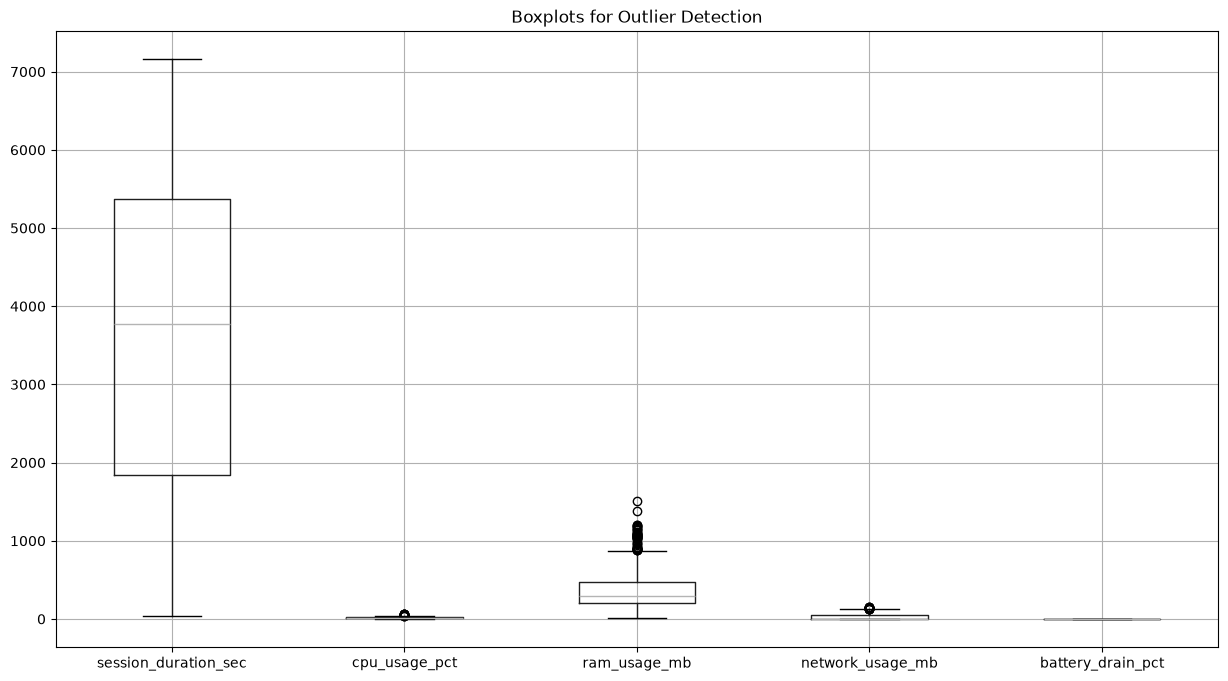

In [289]:
df[['session_duration_sec',
    'cpu_usage_pct',
    'ram_usage_mb',
    'network_usage_mb',
    'battery_drain_pct']].boxplot(figsize=(15, 8))

plt.title('Boxplots for Outlier Detection')
plt.show()

session_duration_sec_outlier     0
cpu_usage_pct_outlier           15
ram_usage_mb_outlier            46
network_usage_mb_outlier        20
battery_drain_pct_outlier        0
dtype: int64


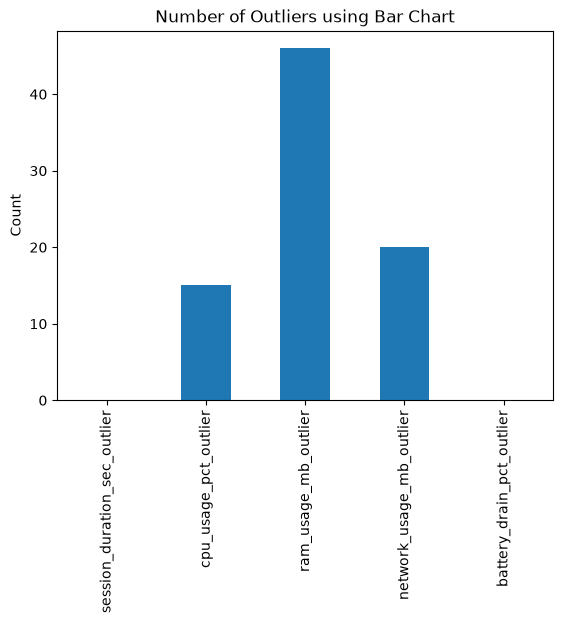

In [290]:
outlier_counts = df.filter(like='_outlier').sum() # count the number of outliers detected in each column
print(outlier_counts)

outlier_counts.plot(kind='bar')
plt.title('Number of Outliers using Bar Chart')
plt.ylabel('Count')
plt.show()

In [291]:
'''
This calculates the chance of a user switching from one app to another. It first counts how many times each app transition
(previous_app >> app_name) appears in the dataset. Then, it calculates the total number of times the user switched away from each previous
app. Using these values, it computes the probability of each app transition by dividing the number of times the transition occurred by the
total number of transitions from that previous app. Finally, the code checks each row in the dataset, finds the probability
of that specific app transition, and saves it in a new column called previous_to_current_probability. If a transition has never been
seen before the code assigns a value of 0.0.
'''

transitions = df.groupby(['previous_app', 'app_name']).size().reset_index(name='count')
totals = transitions.groupby('previous_app')['count'].sum().reset_index(name='total')
transitions = transitions.merge(totals, on='previous_app')
transitions['trans_prob'] = transitions['count']/transitions['total']

lookup = dict(zip(zip(transitions['previous_app'], transitions['app_name']), transitions['trans_prob']))
df['previous to current probability'] = df.apply(lambda r: lookup.get((r['previous_app'], r['app_name']), 0.0), axis=1)

df.head()



,session_id,app_name,app_category,previous_app,timestamp,date,hour_of_day,day_of_week,is_weekend,session_duration_sec,...,battery_drain_pct,is_anomaly,session_duration_min,day_part,session_duration_sec_outlier,cpu_usage_pct_outlier,ram_usage_mb_outlier,network_usage_mb_outlier,battery_drain_pct_outlier,previous to current probability
0,1,Word,Productivity,NONE,2024-01-01 08:00:00,2024-01-01,8,Monday,0,5195,...,0.42,0,86,morning,0,0,0,0,0,1.000000
1,2,Notion,Productivity,Word,2024-01-01 09:30:47,2024-01-01,9,Monday,0,1694,...,0.21,0,28,morning,0,0,0,0,0,0.250000
2,3,Slack,Communication,Notion,2024-01-01 10:02:08,2024-01-01,10,Monday,0,6780,...,2.90,0,113,morning,0,0,0,0,0,0.176471
3,4,Notion,Productivity,Slack,2024-01-01 11:57:14,2024-01-01,11,Monday,0,4861,...,1.48,0,81,morning,0,0,0,0,0,0.224490
4,5,Slack,Communication,Notion,2024-01-01 13:22:03,2024-01-01,13,Monday,0,1851,...,1.40,0,30,afternoon,0,0,0,0,0,0.176471


In [292]:
print("NEW Shape: ", df.shape)

NEW Shape:  (500, 24)
